In [1]:
# setup
from mlwpy import *
%matplotlib inline

In [2]:
diabetes = datasets.load_diabetes()
tts = skms.train_test_split(diabetes.data,
diabetes.target,
test_size=.25)
(diabetes_train_ftrs, diabetes_test_ftrs,
diabetes_train_tgt, diabetes_test_tgt) = tts

In [3]:
diabetes_df = pd.DataFrame(diabetes.data,
columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000


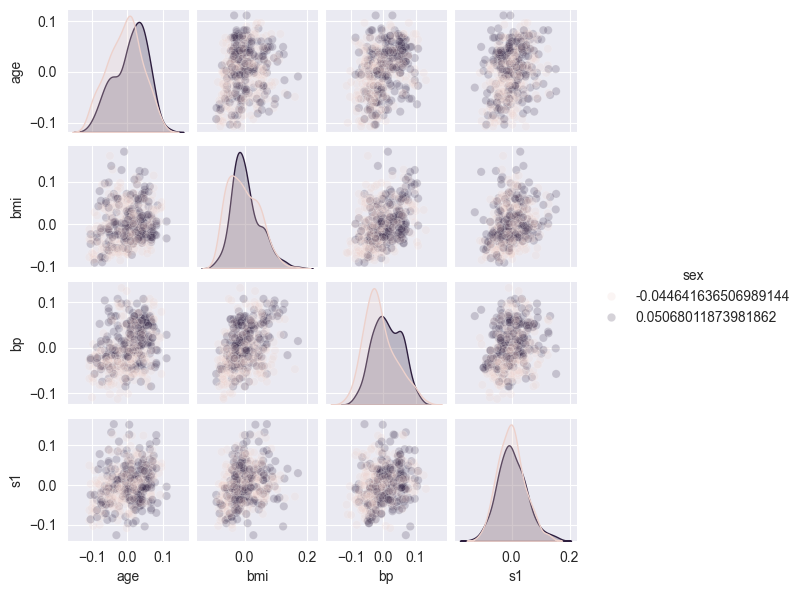

In [5]:
sns.pairplot(diabetes_df[['age', 'sex', 'bmi', 'bp', 's1']],
height=1.5, hue='sex', plot_kws={'alpha':.2});

In [6]:
values = np.array([1, 3, 5, 8, 11, 13, 15])
print("no outlier")
print(np.mean(values),
np.median(values))
values_with_outlier = np.array([1, 3, 5, 8, 11, 13, 40])
print("with outlier")
print("%5.2f" % np.mean(values_with_outlier),
np.median(values_with_outlier))

no outlier
8.0 8.0
with outlier
11.57 8.0


In [7]:
distances = np.array([2.0, 4.0, 4.0])
closeness = 1.0 / distances # element-by-element division
weights = closeness / np.sum(closeness) # normalize sum to one
weights

array([0.5 , 0.25, 0.25])

In [8]:
values = np.array([4, 6, 8])
mean = np.mean(values)
wgt_mean = np.dot(values, weights)
print("Mean:", mean)
print("Weighted Mean:", wgt_mean)

Mean: 6.0
Weighted Mean: 5.5


In [9]:
knn = neighbors.KNeighborsRegressor(n_neighbors=3)
fit = knn.fit(diabetes_train_ftrs, diabetes_train_tgt)
preds = fit.predict(diabetes_test_ftrs)
# evaluate our predictions against the held-back testing targets
metrics.mean_squared_error(diabetes_test_tgt, preds)

3471.41941941942

In [10]:
np.sqrt(3500)

np.float64(59.16079783099616)

In [12]:
def axis_helper(ax, lims):
    'clean up axes'
    ax.set_xlim(lims); ax.set_xticks([])
    ax.set_ylim(lims); ax.set_yticks([])
    ax.set_aspect('equal')

In [13]:
# our data is very simple: two (x, y) points
D = np.array([[3, 5],
[4, 2]])
# we'll take x as our "input" and y as our "output"
x, y = D[:, 0], D[:, 1]

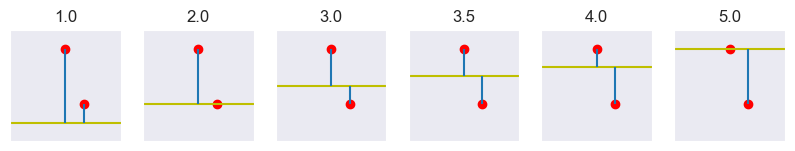

In [14]:
horizontal_lines = np.array([1, 2, 3, 3.5, 4, 5])
results = []
fig, axes = plt.subplots(1, 6, figsize=(10, 5))

for h_line, ax in zip(horizontal_lines, axes.flat):
    # styling
    axis_helper(ax, (0, 6))
    ax.set_title(str(h_line))

    # plot the data
    ax.plot(x, y, 'ro')

    # plot the prediction line
    ax.axhline(h_line, color='y')  # ax coords; defaults to 100%

    # plot the errors
    # the horizontal line *is* our prediction; renaming for clarity
    predictions = h_line
    ax.vlines(x, predictions, y)

    # calculate the error amounts and their sum of squares
    errors = y - predictions
    sse = np.dot(errors, errors)

    # put together some results in a tuple
    results.append((predictions, errors, errors.sum(), sse, np.sqrt(sse)))


In [15]:
col_labels = "Prediction", "Errors", "Sum", "SSE", "Distance"
display(pd.DataFrame.from_records(results,
columns=col_labels,
index="Prediction"))

,Errors,Sum,SSE,Distance
Prediction,,,,
1.0000,"[4.0, 1.0]",5.0000,17.0000,4.1231
2.0000,"[3.0, 0.0]",3.0000,9.0000,3.0000
3.0000,"[2.0, -1.0]",1.0000,5.0000,2.2361
3.5000,"[1.5, -1.5]",0.0000,4.5000,2.1213
4.0000,"[1.0, -2.0]",-1.0000,5.0000,2.2361
5.0000,"[0.0, -3.0]",-3.0000,9.0000,3.0000


In [16]:
def process(D, model, ax):
    # make some useful abbreviations/names
    # y is our "actual"
    x, y = D[:, 0], D[:, 1]
    m, b = model

    # styling
    axis_helper(ax, (0, 8))

    # plot the data
    ax.plot(x, y, 'ro')

    # plot the prediction line
    helper_xs = np.array([0, 8])
    helper_line = m * helper_xs + b
    ax.plot(helper_xs, helper_line, color='y')

    # plot the errors
    predictions = m * x + b
    ax.vlines(x, predictions, y)

    # calculate error amounts
    errors = y - predictions

    # tuple up the result
    sse = np.dot(errors, errors)
    return (errors, errors.sum(), sse, np.sqrt(sse))


,Raw Errors,Sum,SSE,TotDist
0,"[2, -2]",0,8,2.8284
1,"[1, -3]",-2,10,3.1623
2,"[0, -4]",-4,16,4.0000
3,"[0, -2]",-2,4,2.0000
4,"[0, 0]",0,0,0.0000


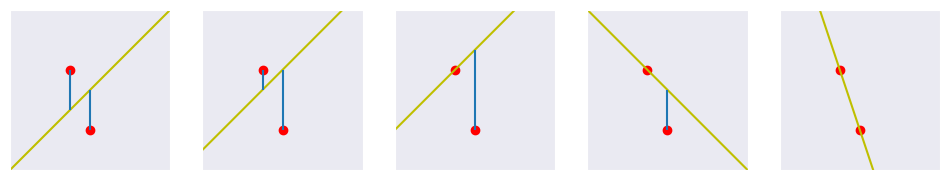

In [17]:
# our data is very simple: two (x, y) points
D = np.array([[3, 5],
[4, 2]])
# m b --> predictions = mx + b
lines_mb = np.array([[ 1, 0],
[ 1, 1],
[ 1, 2],
[-1, 8],
[-3, 14]])
col_labels = ("Raw Errors", "Sum", "SSE", "TotDist")
results = []
# note: plotting occurs in process()
fig, axes = plt.subplots(1, 5, figsize=(12, 6))
records = [process(D, mod, ax) for mod,ax in zip(lines_mb, axes.flat)]
df = pd.DataFrame.from_records(records, columns=col_labels)
display(df)

In [18]:
lr = linear_model.LinearRegression()
fit = lr.fit(diabetes_train_ftrs, diabetes_train_tgt)
preds = fit.predict(diabetes_test_ftrs)
# evaluate our predictions against the unseen testing targets
metrics.mean_squared_error(diabetes_test_tgt, preds)

2848.3106508475043

In [19]:
tgt = np.array([3, 5, 8, 10, 12, 15])

In [21]:
# random guesses with some constraints
num_guesses = 10
results = []
for g in range(num_guesses):
    guess = np.random.uniform(low=tgt.min(), high=tgt.max())
    total_dist = np.sum((tgt - guess)**2)
    results.append((total_dist, guess))
best_guess = sorted(results)[0][1]
best_guess

8.228074784134693

In [22]:
# use a random choice to take a hypothetical
# step up or down: follow it, if it is an improvement
num_steps = 100
step_size = 0.05

best_guess = np.random.uniform(low=tgt.min(), high=tgt.max())
best_dist = np.sum((tgt - best_guess)**2)

for s in range(num_steps):
    new_guess = best_guess + (np.random.choice([+1, -1]) * step_size)
    new_dist = np.sum((tgt - new_guess)**2)
    if new_dist < best_dist:
        best_guess, best_dist = new_guess, new_dist

print(best_guess)


8.836959712695537


In [23]:
# hypothetically take both steps (up and down)
# choose the better of the two
# if it is an improvement, follow that step

num_steps = 1000
step_size = 0.02

best_guess = np.random.uniform(low=tgt.min(), high=tgt.max())
best_dist = np.sum((tgt - best_guess) ** 2)

print("start:", best_guess)

for s in range(num_steps):
    # np.newaxis is needed to align the minus
    guesses = best_guess + (np.array([-1, 1]) * step_size)
    dists = np.sum((tgt[:, np.newaxis] - guesses) ** 2, axis=0)
    better_idx = np.argmin(dists)

    if dists[better_idx] > best_dist:
        break

    best_guess = guesses[better_idx]
    best_dist = dists[better_idx]

print(" end:", best_guess)


start: 9.575662598977047
 end: 8.835662598977063


In [24]:
print("mean:", np.mean(tgt))

mean: 8.833333333333334


In [25]:
# stand-alone code
from sklearn import datasets, neighbors, model_selection as skms, linear_model, metrics

# Load data
diabetes = datasets.load_diabetes()

# Train/test split
tts = skms.train_test_split(diabetes.data, diabetes.target, test_size=0.25)
(diabetes_train, diabetes_test, diabetes_train_tgt, diabetes_test_tgt) = tts

# Define models
models = {
    'kNN': neighbors.KNeighborsRegressor(n_neighbors=3),
    'linreg': linear_model.LinearRegression()
}

# Fit and evaluate
for name, model in models.items():
    fit = model.fit(diabetes_train, diabetes_train_tgt)
    preds = fit.predict(diabetes_test)
    score = np.sqrt(metrics.mean_squared_error(diabetes_test_tgt, preds))
    print("{:>6s} : {:0.2f}".format(name, score))


   kNN : 54.85
linreg : 46.95


In [33]:
!python scripts/perf_02.py mem lr
!python scripts/perf_02.py time lr

lr_go : ~0.5195 MiB
lr_go : ~0.0408 sec


In [34]:
!python scripts/perf_02.py mem knn
!python scripts/perf_02.py time knn

knn_go: ~0.3398 MiB
knn_go: ~0.1004 sec
